In [1]:
# !pip install astropy
import rebound
import reboundx
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
from multiprocess import Pool

In [2]:
sa = rebound.Simulationarchive("resolved.bin")
print("Number of snapshots: %d" % len(sa))
print("Time of first and last snapshot: %.1f, %.1f" % (sa.tmin, sa.tmax))

Number of snapshots: 15001
Time of first and last snapshot: 0.0, -30000000.0


In [3]:
sa.tmax/(1*1e6)

-30.0

In [4]:
sa = rebound.Simulationarchive("quad.bin")
print("Number of snapshots: %d" % len(sa))
print("Time of first and last snapshot: %.1f, %.1f" % (sa.tmin, sa.tmax))

Number of snapshots: 97029
Time of first and last snapshot: -30000000.0, -999760000.0


In [5]:
sa.tmax/(1*1e9)

-0.9997599999959635

In [6]:
sa = rebound.Simulationarchive("quad_early.bin")
print("Number of snapshots: %d" % len(sa))
print("Time of first and last snapshot: %.1f, %.1f" % (sa.tmin, sa.tmax))

Number of snapshots: 3001
Time of first and last snapshot: 0.0, -30000000.0


In [7]:
sa.tmax/(1*1e6)

-30.0

In [8]:
sa = rebound.Simulationarchive("barycenter.bin")
print("Number of snapshots: %d" % len(sa))
print("Time of first and last snapshot: %.1f, %.1f" % (sa.tmin, sa.tmax))

Number of snapshots: 3001
Time of first and last snapshot: 0.0, -30000000.0


In [9]:
sa.tmax/(3*1e7)

-1.0

In [10]:
sa = rebound.Simulationarchive("barycenter.bin")

es = np.zeros(len(sa))
ps = np.zeros(len(sa))
times = np.zeros(len(sa))
E1 = np.zeros(len(sa))
Eerr = np.zeros(len(sa))

for i, sim in enumerate(sa):
    sim.move_to_com
    qps = sim.particles
    rebx = reboundx.Extras(sim)
        # add GR
    gr = rebx.load_force('gr_potential')
    rebx.add_force(gr)
    gr.params['c'] = 63240 # speed of light in AU/yr
    
    es[i] = sim.particles['earth'].e
    ps[i]=sim.particles['earth'].pomega
    times[i] = sim.t
    
    if i==0:
        E0 = sim.energy()
        
    E = sim.energy()
    E1[i] = E
    Eerr[i] = np.abs((E-E0)/E0)

/home/miniconda3/envs/ahekster/lib/python3.12/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [11]:
sa = rebound.Simulationarchive("quad.bin")

es3 = np.zeros(len(sa))
ps3 = np.zeros(len(sa))
E3 = np.zeros(len(sa))
Eerr3 = np.zeros(len(sa))
times3 = np.zeros(len(sa))

for i, sim in enumerate(sa):
    sim.move_to_com
    qps = sim.particles
    rebx = reboundx.Extras(sim)
        # add GR
    gr = rebx.load_force('gr_potential')
    rebx.add_force(gr)
    gr.params['c'] = 63240 # speed of light in AU/yr
    
    cf = rebx.load_force("quadrupole")
    rebx.add_force(cf)
    earth_m = qps['earth'].m/1.012
    f = 0.8525
    mu_eff = f*(1*0.012*(earth_m)**2)/(1.012*earth_m)
    A = -1 * 3 * sim.G * qps['sun'].m / (4 * qps['earth'].m)
    R = 0.0025696

    qps['earth'].params["Rcentral"] = R
    qps['earth'].params["mu_effcentral"] = mu_eff

    if i==0:
        E0 = sim.energy()+ rebx.quad_force_potential()

    es3[i] = sim.particles['earth'].e
    ps3[i]=sim.particles['earth'].pomega
    times3[i] = sim.t
    E = sim.energy() + rebx.quad_force_potential()
    E3[i] = E
    Eerr3[i] = np.abs((E-E0)/E0)

In [12]:
sa = rebound.Simulationarchive("quad_early.bin")

es4 = np.zeros(len(sa))
ps4 = np.zeros(len(sa))
E4 = np.zeros(len(sa))
Eerr4 = np.zeros(len(sa))
times4 = np.zeros(len(sa))

for i, sim in enumerate(sa):
    sim.move_to_com
    qps = sim.particles
    rebx = reboundx.Extras(sim)
        # add GR
    gr = rebx.load_force('gr_potential')
    rebx.add_force(gr)
    gr.params['c'] = 63240 # speed of light in AU/yr
    
    cf = rebx.load_force("quadrupole")
    rebx.add_force(cf)
    earth_m = qps['earth'].m/1.012
    f = 0.8525
    mu_eff = f*(1*0.012*(earth_m)**2)/(1.012*earth_m)
    A = -1 * 3 * sim.G * qps['sun'].m / (4 * qps['earth'].m)
    R = 0.0025696

    qps['earth'].params["Rcentral"] = R
    qps['earth'].params["mu_effcentral"] = mu_eff

    if i==0:
        E0 = sim.energy() + rebx.quad_force_potential()

    es4[i] = sim.particles['earth'].e
    ps4[i]=sim.particles['earth'].pomega
    times4[i] = sim.t
    E = sim.energy() + rebx.quad_force_potential()
    E4[i] = E
    Eerr4[i] = np.abs((E-E0)/E0)

In [13]:
sa = rebound.Simulationarchive("resolved.bin")

es2 = np.zeros(len(sa))
ps2 = np.zeros(len(sa))
times2 = np.zeros(len(sa))
E2 = np.zeros(len(sa))
Eerr2 = np.zeros(len(sa))
for i, sim in enumerate(sa):
    sim.move_to_com
    qps = sim.particles
    rebx = reboundx.Extras(sim)
        # add GR
    gr = rebx.load_force('gr_potential')
    rebx.add_force(gr)
    gr.params['c'] = 63240 # speed of light in AU/yr
    
    if i==0:
        E0 = sim.energy()
        
    E = sim.energy()
    E2[i] = E
    Eerr2[i] = np.abs((E-E0)/E0)
    
    es2[i] = sim.particles['earth'].e
    ps2[i]=sim.particles['earth'].pomega
    times2[i] = sim.t

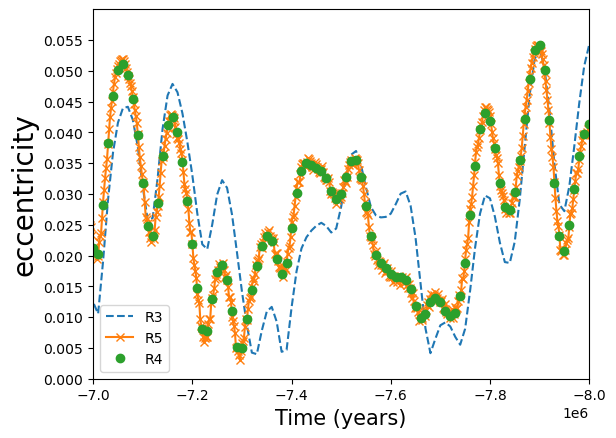

In [14]:
plt.plot(times, es, '--', label = 'R3')
plt.plot(times2, es2, 'x-', label='R5')
plt.plot(times4, es4, 'o', label='R4')
# plt.plot(times, es, '.')
plt.ylabel("eccentricity", fontsize=20)
# plt.xlim(-23.8*1e6, -24.1*1e6)
plt.xlim(-7*1e6, -8*1e6)
plt.ylim(0,0.06)
plt.xlabel("Time (years)", fontsize=15)
plt.legend()
plt.yticks(np.arange(0,0.06,0.005))
# plt.xticks(-np.arange(7*1e6,8.1*1e6,1*1e5))
plt.legend()
plt.show()

# plt.plot(times, ps, '.')
# plt.ylabel("pomega", fontsize=24)
# plt.xlim(-23.8*1e6, -24.1*1e6)
# plt.show()

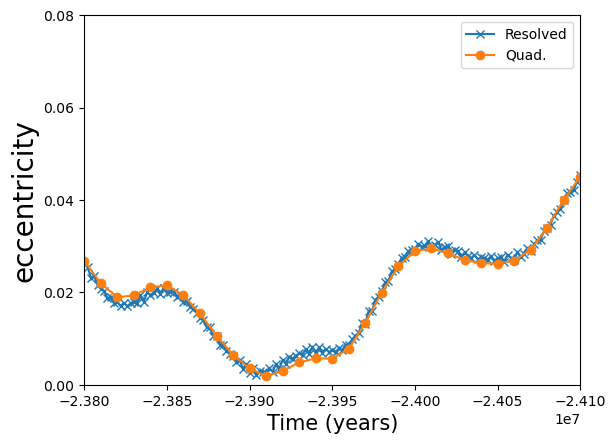

In [15]:
# plt.plot(times, es, '--', label = 'Barycenter')
plt.plot(times2, es2, 'x-', label='Resolved')
plt.plot(times4, es4, 'o-', label='Quad.')
# plt.plot(times, es, '.')
plt.ylabel("eccentricity", fontsize=20)
plt.xlim(-23.8*1e6, -24.1*1e6)
# plt.xlim(-7*1e6, -8*1e6)
plt.ylim(0,0.08)
plt.xlabel("Time (years)", fontsize=15)
plt.legend()
plt.yticks(np.arange(0,0.081,0.02))
# plt.xticks(-np.arange(7*1e6,8.1*1e6,1*1e5))
plt.legend()
plt.show()

# plt.plot(times, ps, '.')
# plt.ylabel("pomega", fontsize=24)
# plt.xlim(-23.8*1e6, -24.1*1e6)
# plt.show()

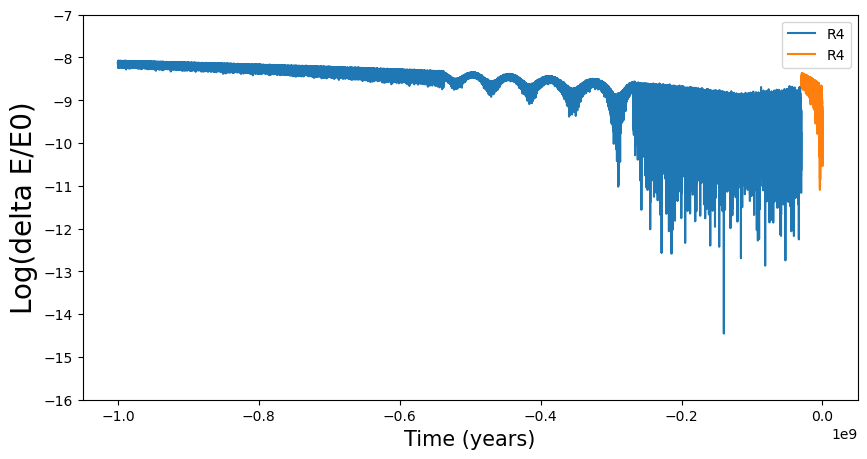

In [22]:
plt.figure(figsize=[10,5])
plt.plot(times3[2::], np.log10(np.abs((E3[2::]-E3[0])/E3[0])), '-', label='R4')
plt.plot(times[2::], np.log10(np.abs((E1[2::]-E1[0])/E1[0])), '-', label='R4')
plt.ylim(-16,-7)
# plt.xlim(np.min(times3),np.max(times3))
plt.ylabel("Log(delta E/E0)", fontsize=20)
plt.xlabel("Time (years)", fontsize=15)
plt.legend()
plt.legend()
plt.show()

In [17]:
np.abs((E3[2::]-E3[0])/E3[0])

array([2.42457510e-11, 1.24021676e-10, 1.65446441e-10, ...,
       5.91966882e-09, 5.83139781e-09, 6.71351297e-09])